In [9]:
!pip install "matplotlib>=3.8,<3.9" --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 18.3 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.7.5
    Uninstalling matplotlib-3.7.5:
      Successfully uninstalled matplotlib-3.7.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gwaslab 4.1.1 requires pandas!=1.5,<=2.3.3,>=1.3, but you have pandas 3.0.1 which is incompatible.

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


2026/02/24 10:00:46 GWASLab v4.1.1 https://cloufield.github.io/gwaslab/
2026/02/24 10:00:46 (C) 2022-2026, Yunye He, Kamatani Lab, GPL-3.0 license, gwaslab@gmail.com
2026/02/24 10:00:46 Python version: 3.11.14 (main, Oct  9 2025, 16:16:55) [Clang 17.0.0 (clang-1700.6.3.2)]
2026/02/24 10:00:46 Start to load format from formatbook....
2026/02/24 10:00:46  -plink2 format meta info:
2026/02/24 10:00:46   - format_name  : PLINK2 .glm.firth, .glm.logistic,.glm.linear
2026/02/24 10:00:46   - format_source  : https://www.cog-genomics.org/plink/2.0/formats
2026/02/24 10:00:46   - format_version  : Alpha 3.3 final (3 Jun)
2026/02/24 10:00:46   - last_check_date  :  20220806
2026/02/24 10:00:46  -plink2 to gwaslab format dictionary:
2026/02/24 10:00:46   - plink2 keys: ID,#CHROM,POS,REF,ALT,A1,OBS_CT,A1_FREQ,BETA,LOG(OR)_SE,SE,T_STAT,Z_STAT,P,LOG10_P,MACH_R2,OR
2026/02/24 10:00:46   - gwaslab values: SNPID,CHR,POS,REF,ALT,EA,N,EAF,BETA,SE,SE,T,Z,P,MLOG10P,INFO,OR
2026/02/24 10:00:46  -Top 3 infer

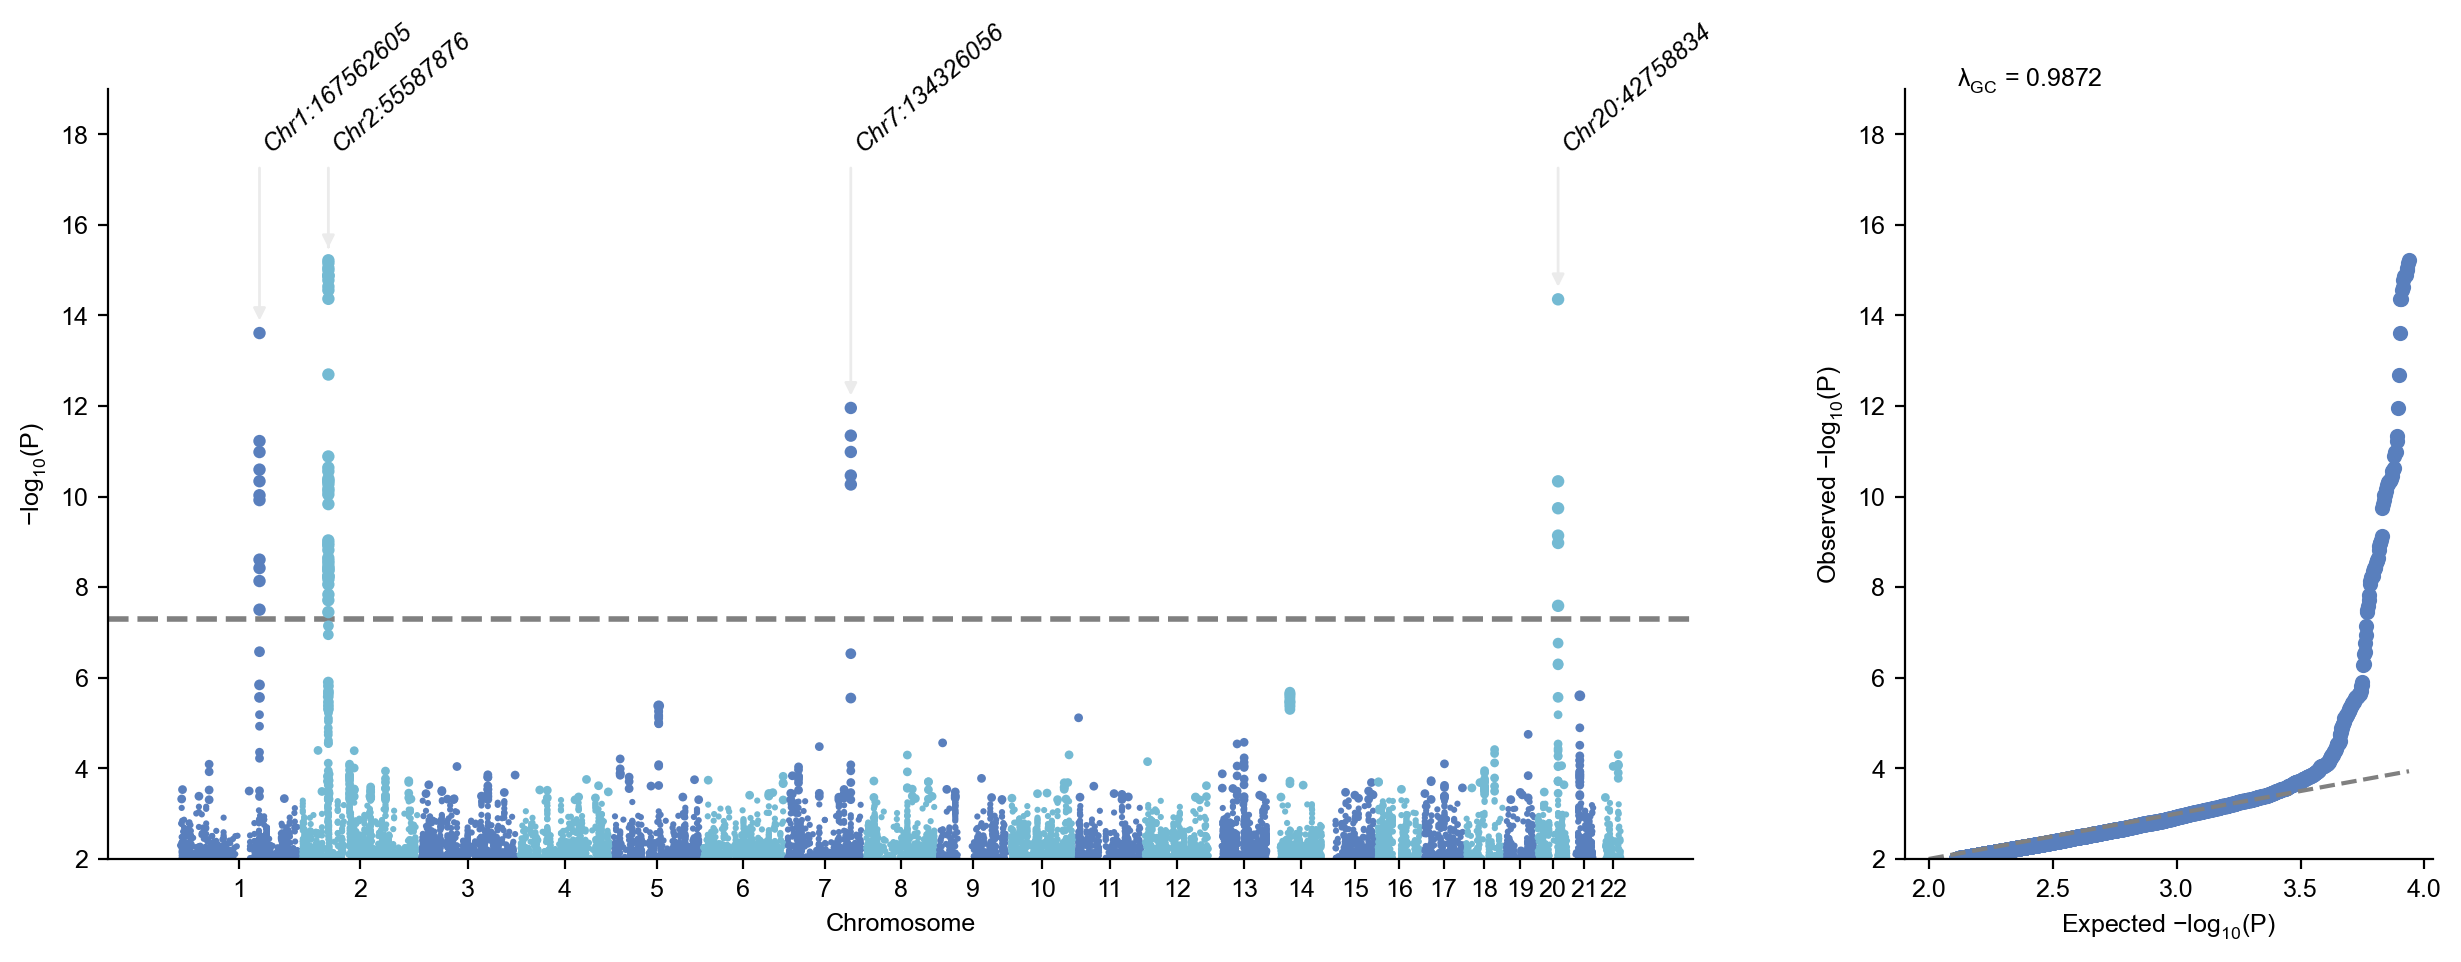

In [ ]:
#import the library necessary for the analysis
#the library is called gwaslab and it is a python library for the analysis of 
# genome-wide association studies (GWAS) data. It provides tools for data manipulation, 
# statistical analysis, and visualization of GWAS results.
#GWAS is a method used to identify genetic variants associated with traits or 
# diseases by scanning the genome for associations between genetic markers 
# and phenotypic traits.
import gwaslab as gl

# Load the data using the absolute path
path = "/Users/noushinhaque/Downloads/gwas_required_documents/1kgeas_results.B1.glm.firth"

#sumstats is a class in the gwaslab library that represents the summary statistics of a GWAS analysis.
#It provides methods for manipulating and analyzing the summary statistics data, such as identifying 
# significant peaks, creating plots, and performing various statistical analyses.
# gl.sumstats() takes the path to the summary statistics file and the format of the file 
# (in this case, "plink2") as arguments and loads the data into a sumstats object for 
# further analysis.
sumstats = gl.Sumstats(path, fmt="plink2")

#Identify the significant peaks
#get_lead() is a method of the sumstats class that identifies the lead variants, 
# which are the most significant variants in a given region of the genome.
#variants imply the specific genetic variations (such as single nucleotide polymorphisms or SNPs) 
# that are associated with a trait or disease in a GWAS analysis.
# The sig_level parameter specifies the significance threshold for identifying lead variants,
# in this case, 5e-8, which is a commonly used threshold for genome-wide significance in GWAS studies.
lead_variants = sumstats.get_lead(sig_level=5e-8)
print("Lead Variants:")
print(lead_variants)

#Create the Manhattan and QQ plots

#The manhattan plot is a type of scatter plot used in GWAS to visualize the association between genetic 
# variants and traits across the genome. Each point on the plot represents a genetic variant, with the 
# x-axis representing the chromosome number and the y-axis representing the negative log10 of the p-value.
# this shows the significant peaks in the data, which are the variants that are most strongly associated 
# with the trait
# the trait is the phenotype or characteristic being studied in the GWAS analysis, such as a disease or 
# a physical trait.
sumstats.plot_mqq(
    skip=2, 
    anno=True, 
    save=True
)

The QQ Plot (Right) & λGC: top left of your QQ plot—your Lambda GC (λGC) is 0.9872. A value this close to 1.0 is great. It means the model has excellent genomic control and the data is clean. There is almost zero inflation from confounding factors like population stratification. The points hugging the diagonal dashed line and then shooting straight up at the end is the textbook definition of a successful association test.

The Manhattan Plot (Left): several very clear "towers" of blue dots that cross the genome-wide significance threshold (the horizontal dashed line at P=5×10 
e−8). The software has automatically annotated these lead variants at the top of the peaks. These are the true genetic associations.

In [ ]:
# Runs a comprehensive quality control check on your data
#this summary stats give us a basic check of the data, including the number of variants, 
# the distribution of p-values, and other important metrics that can help us assess the quality of our GWAS 
# results before we proceed with further analysis
sumstats.basic_check()

2026/02/24 09:52:17 Start to check SNPID/rsID ...(v4.1.1)
2026/02/24 09:52:17  -Checking SNPID data type...
2026/02/24 09:52:17  -Checking if SNPID contains NA strings :na,NA,Na,Nan,NaN,<NA>,null,NULL,#N/A,#VALUE!,N/A,n/a,missing,...
2026/02/24 09:52:17  -Checking if SNPID is CHR:POS:NEA:EA...(separator: - ,: , _)
2026/02/24 09:52:17  -Time taken: 0.098s
2026/02/24 09:52:17 Finished checking SNPID/rsID.
2026/02/24 09:52:17 Start to fix chromosome notation (CHR) ...(v4.1.1)
2026/02/24 09:52:17  -Checking CHR data type...
2026/02/24 09:52:17  -Variants with standardized chromosome notation: 1137882
2026/02/24 09:52:17  -All CHR are already fixed...
2026/02/24 09:52:17  -Time taken: 0.133s
2026/02/24 09:52:17 Finished fixing chromosome notation (CHR).
2026/02/24 09:52:17 Start to fix basepair positions (POS) ...(v4.1.1)
2026/02/24 09:52:17  -Trying to convert datatype for POS: int64 -> Int64...
2026/02/24 09:52:17  -Position bound:(0 , 250,000,000)
2026/02/24 09:52:17  -No outlier variant

,SNPID,CHR,POS,EA,NEA,STATUS,REF,ALT,EAF,SE,OR,Z,P,N
0,1:14930:A:G,1,14930,G,A,9960099,A,G,0.413000,0.225997,0.784097,-1.076220,0.281830,500
1,1:15774:G:A,1,15774,A,G,9960099,G,A,0.028056,0.394788,0.747606,-0.736799,0.461245,499
2,1:15777:A:G,1,15777,G,A,9960099,A,G,0.074148,0.248796,0.847690,-0.664157,0.506590,499
3,1:57292:C:T,1,57292,T,C,9960099,C,T,0.104839,0.214398,1.152290,0.661156,0.508512,496
4,1:77874:G:A,1,77874,A,G,9960099,G,A,0.020000,0.452089,1.227290,0.453031,0.650527,500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1137869,22:51217954:G:A,22,51217954,A,G,9960099,G,A,0.032934,0.362326,0.712410,-0.935901,0.349324,501
1137870,22:51218377:G:C,22,51218377,C,G,9960099,G,C,0.033066,0.362367,0.712738,-0.934529,0.350031,499
1137871,22:51218615:T:A,22,51218615,A,T,9960099,T,A,0.033000,0.362626,0.703817,-0.968592,0.332749,500
1137872,22:51222100:G:T,22,51222100,T,G,9960099,G,T,0.038845,0.322806,1.238970,0.663806,0.506815,502


2026/02/24 09:52:31 Filtered out args for `plot_mqq`: highlight
2026/02/24 09:52:31 #WARNING! Build is unknown. .infer_build first.
2026/02/24 09:52:31 Configured plot style for plot_mqq:r
2026/02/24 09:52:31  -QC is finished according to meta. Quick QC will be skipped.
2026/02/24 09:52:31 Starting Region plot creation (Version v4.1.1)
2026/02/24 09:52:31 #WARNING! Version of genomic coordinates is unknown for homo sapiens (build: 99)...
2026/02/24 09:52:31  - Genomic coordinates version: 99 ...
2026/02/24 09:52:31 #WARNING! Genomic coordinates version is unknown.
2026/02/24 09:52:31  - Genome-wide significance level to plot is set to 5e-08 ...
2026/02/24 09:52:31  - Input sumstats contains 1137874 variants...
2026/02/24 09:52:31  - Region plot layout mode selected: r
2026/02/24 09:52:31  -Region to plot : chr2:54513738-56513738.
2026/02/24 09:52:31  -Normalized region: (CHR=2, START=54513738, END=56513738)
2026/02/24 09:52:31 Start to filter variants within a specific genomic region .

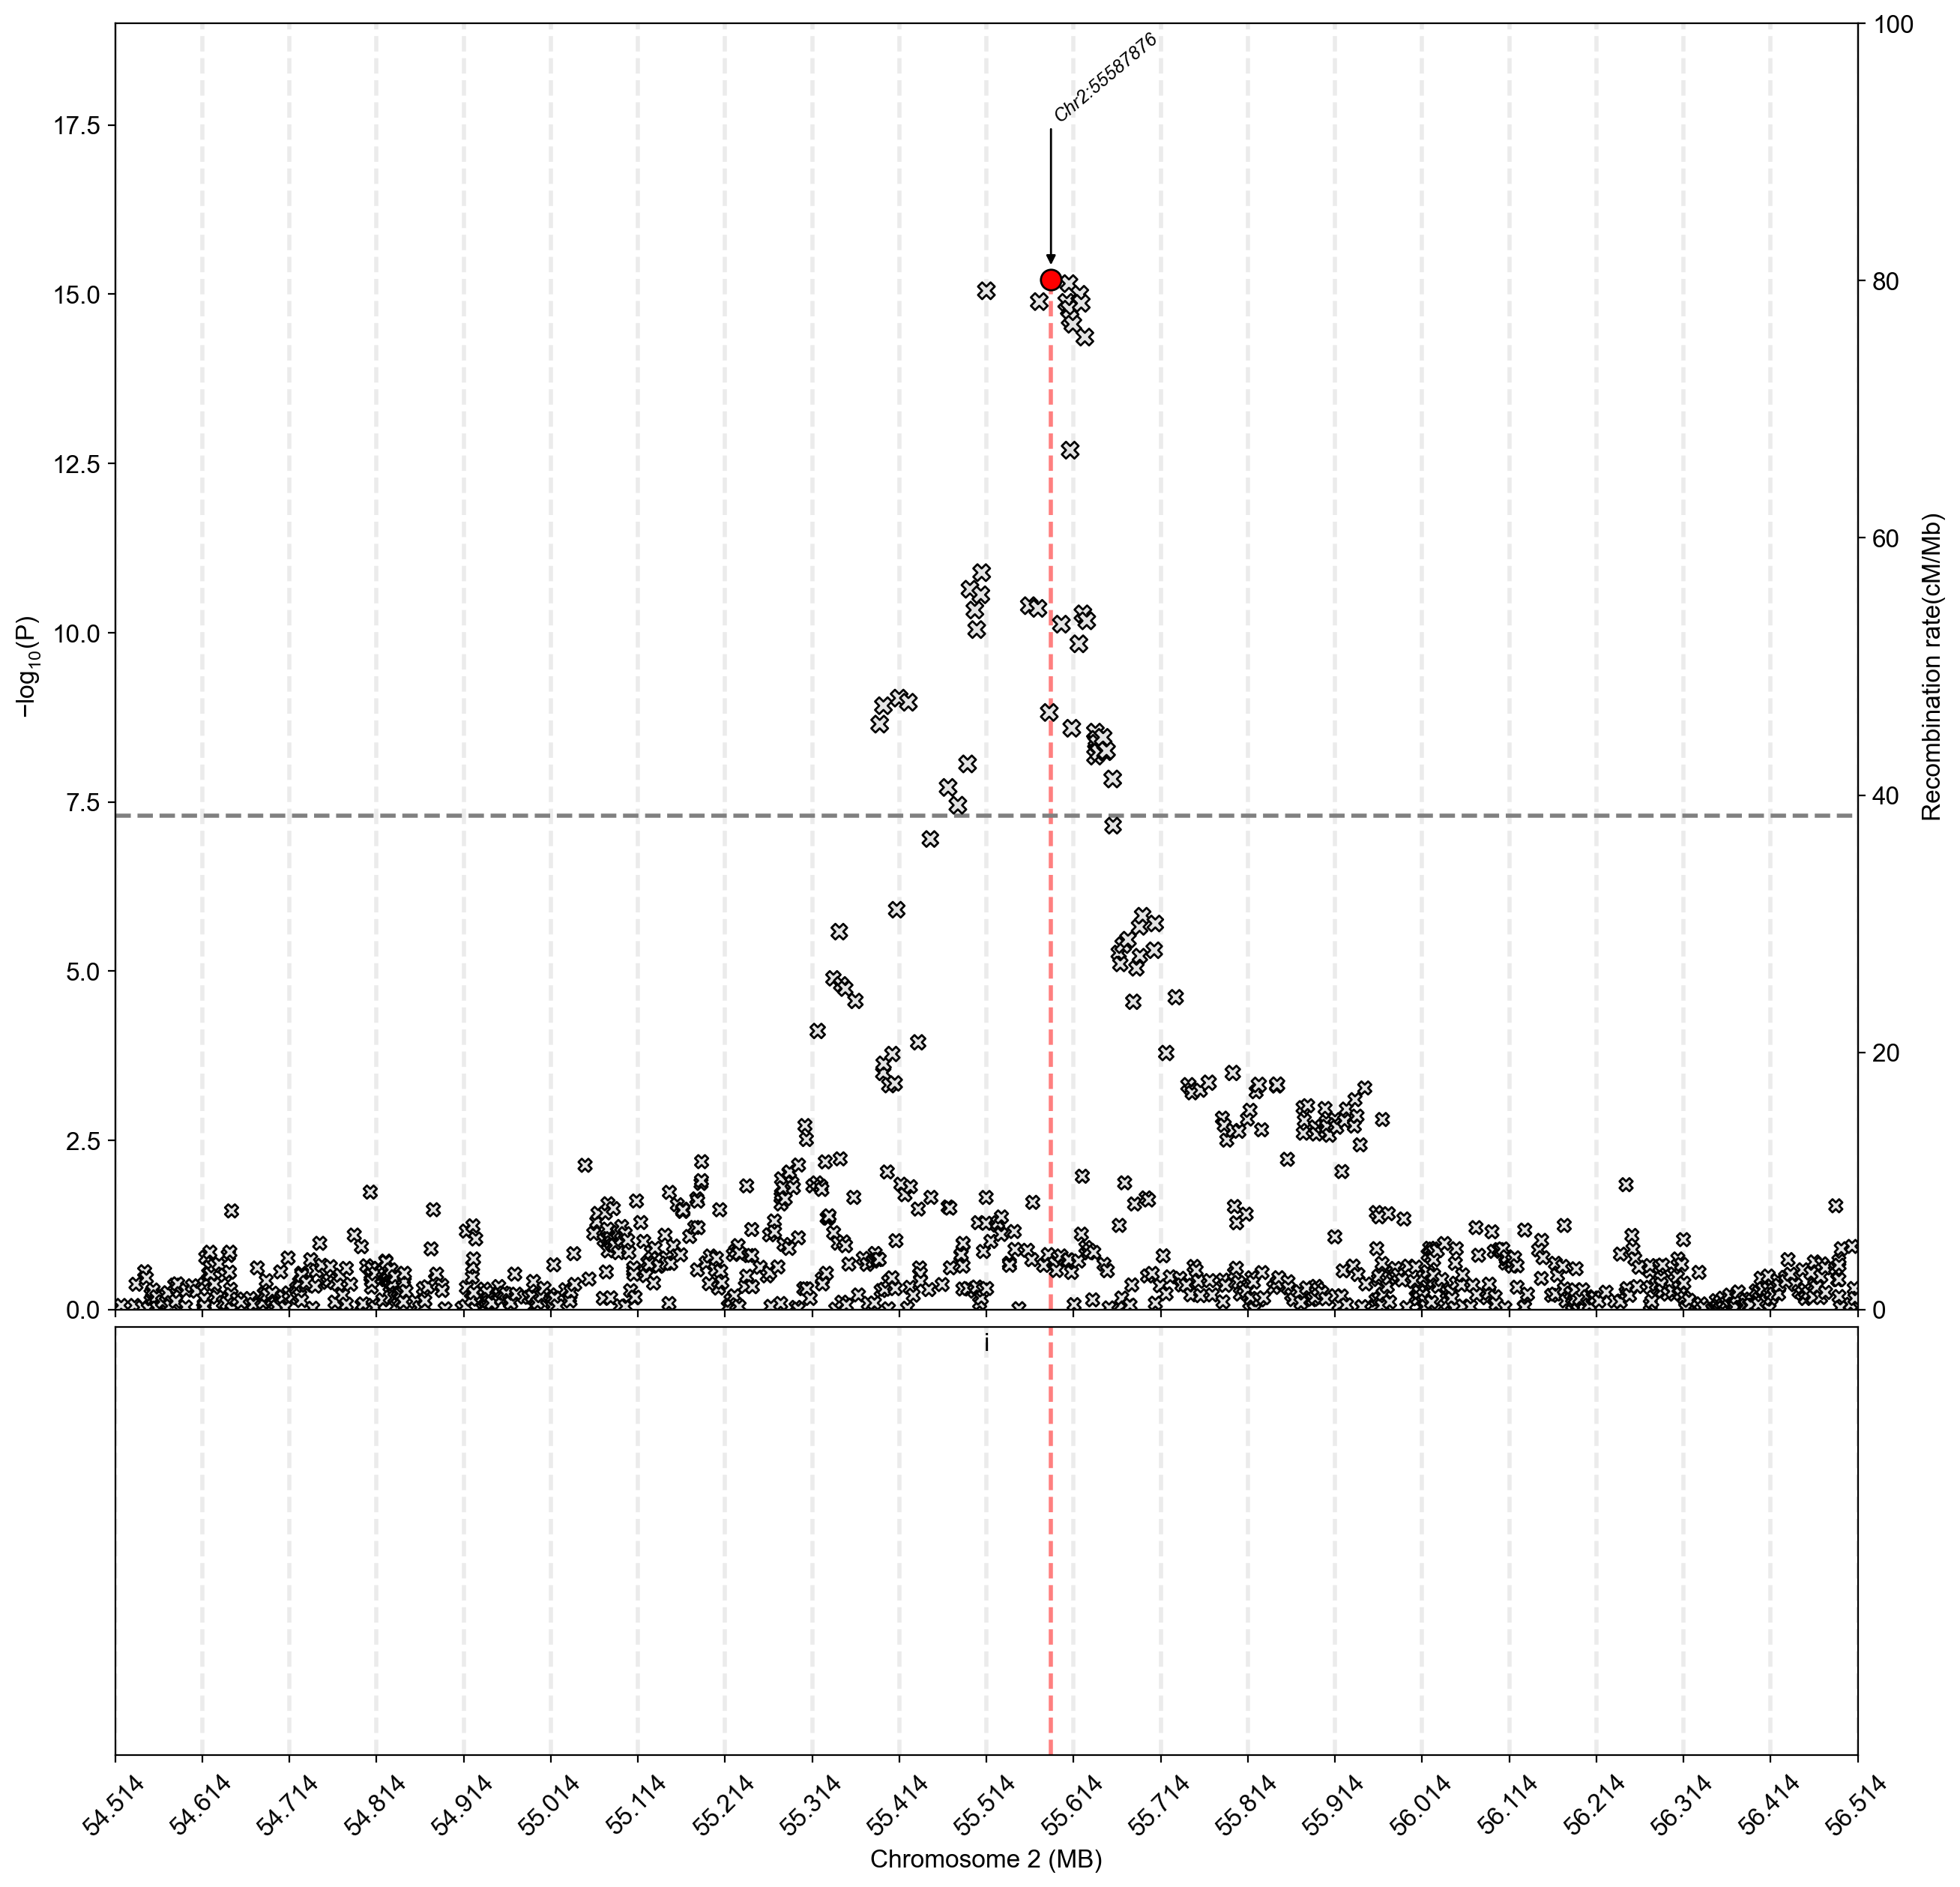

In [ ]:
# Zoom in on Chromosome 2, between base pairs 54,513,738 and 56,513,738
#the following code creates a regional plot (also known as a locus zoom plot) for a specific region of the genome,
# which is defined by the chromosome number (2) and the base pair positions (54,513,738 to 56,513,738).
# The mode="r" argument specifies that the plot should be a regional plot, which focuses on a specific region
# of the genome rather than the entire genome. The anno=True argument indicates that the plot should include 
# annotations, such as gene names or other relevant information about the variants in the region. 
# The region_grid=True argument adds grid lines to the plot for better visualization of the data points. 
# The build="19" argument specifies that the genome build being used is hg19 (GRCh37), which is a commonly 
# used reference genome in human genetics. Finally, the save=True argument indicates that the plot should be 
# saved to a file for later use or sharing.

sumstats.plot_mqq(
    mode="r",
    anno=True,
    region=(2, 54513738, 56513738),
    region_grid=True,
    build="19", # Assumes genome build hg19 (GRCh37)
    save=True
)

In [ ]:
#this above code creates a regional plot (also known as a locus zoom plot) 
#for a specific region of the genome, which is defined by the chromosome number (2) 
#and the base pair positions (54,513,738 to 56,513,738). 

#Some code line explanations:
# The mode="r" argument specifies that the plot should be a regional plot, 
# which focuses on a specific region of the genome rather than the entire genome.
# The region_grid=True argument adds grid lines to the plot for better visualization of the data points. 
# The build="19" argument specifies that the genome build being used is hg19 (GRCh37), which is a commonly 
# used reference genome in human genetics. 
# Finally, the save=True argument indicates that the plot should be saved to a file for later use or sharing.       


#This overall plot helps us visualize the association between genetic variants 
# and traits in a specific region of the genome, where all the base pairs are located.
# By zooming in on this region, we can identify specific variants that may be associated 
# with the trait of interest, and the red dashed line indicates the significance threshold 
# for identifying lead variants. The red dot shows the lead variant in this region, 
# which is the most significant variant associated with the trait. 

#having all the base pairs associated with that chromosome and region displayed in 
# the plot allows us to see the distribution of variants in this region and identify any patterns or clusters 
# of variants that may be associated with the trait.

In [ ]:
# Download the 1000 Genomes East Asian (EAS) reference panel for hg19
import gwaslab as gl
#this code uses the gwaslab library to download the 1000 Genomes East Asian (EAS) reference panel for the hg19 
# genome build. We get the LD information for the variants in our summary statistics file using the EAS reference panel,
# which allows us to focus on the genetic variants that are specific to the East Asian population in our analysis.
gl.download_ref("1kg_eas_hg19")


2026/02/24 13:10:50 Start to download  1kg_eas_hg19  ...
2026/02/24 13:10:50  -Downloading to: /Users/noushinhaque/.gwaslab/EAS.ALL.split_norm_af.1kgp3v5.hg19.vcf.gz
2026/02/24 13:10:50  -File /Users/noushinhaque/.gwaslab/EAS.ALL.split_norm_af.1kgp3v5.hg19.vcf.gz exists.
2026/02/24 13:10:50  - Updating record in config file...
2026/02/24 13:10:50  -Downloading to: /Users/noushinhaque/.gwaslab/EAS.ALL.split_norm_af.1kgp3v5.hg19.vcf.gz.tbi
2026/02/24 13:10:50  -File /Users/noushinhaque/.gwaslab/EAS.ALL.split_norm_af.1kgp3v5.hg19.vcf.gz.tbi exists.
2026/02/24 13:10:50  - Updating record in config file...
2026/02/24 13:10:50 Downloaded  1kg_eas_hg19  successfully!


2026/02/24 09:54:01 Filtered out args for `plot_mqq`: highlight
2026/02/24 09:54:01 #WARNING! Build is unknown. .infer_build first.
2026/02/24 09:54:01 Configured plot style for plot_mqq:r
2026/02/24 09:54:01  -QC is finished according to meta. Quick QC will be skipped.
2026/02/24 09:54:01 Starting Region plot creation (Version v4.1.1)
2026/02/24 09:54:01 #WARNING! Version of genomic coordinates is unknown for homo sapiens (build: 99)...
2026/02/24 09:54:01  - Genomic coordinates version: 99 ...
2026/02/24 09:54:01 #WARNING! Genomic coordinates version is unknown.
2026/02/24 09:54:01  - Genome-wide significance level to plot is set to 5e-08 ...
2026/02/24 09:54:01  - Input sumstats contains 1137874 variants...
2026/02/24 09:54:01  - Region plot layout mode selected: r
2026/02/24 09:54:01  -Region to plot : chr2:54531536-56731536.
2026/02/24 09:54:01  -Normalized region: (CHR=2, START=54531536, END=56731536)
2026/02/24 09:54:01 Start to filter variants within a specific genomic region .

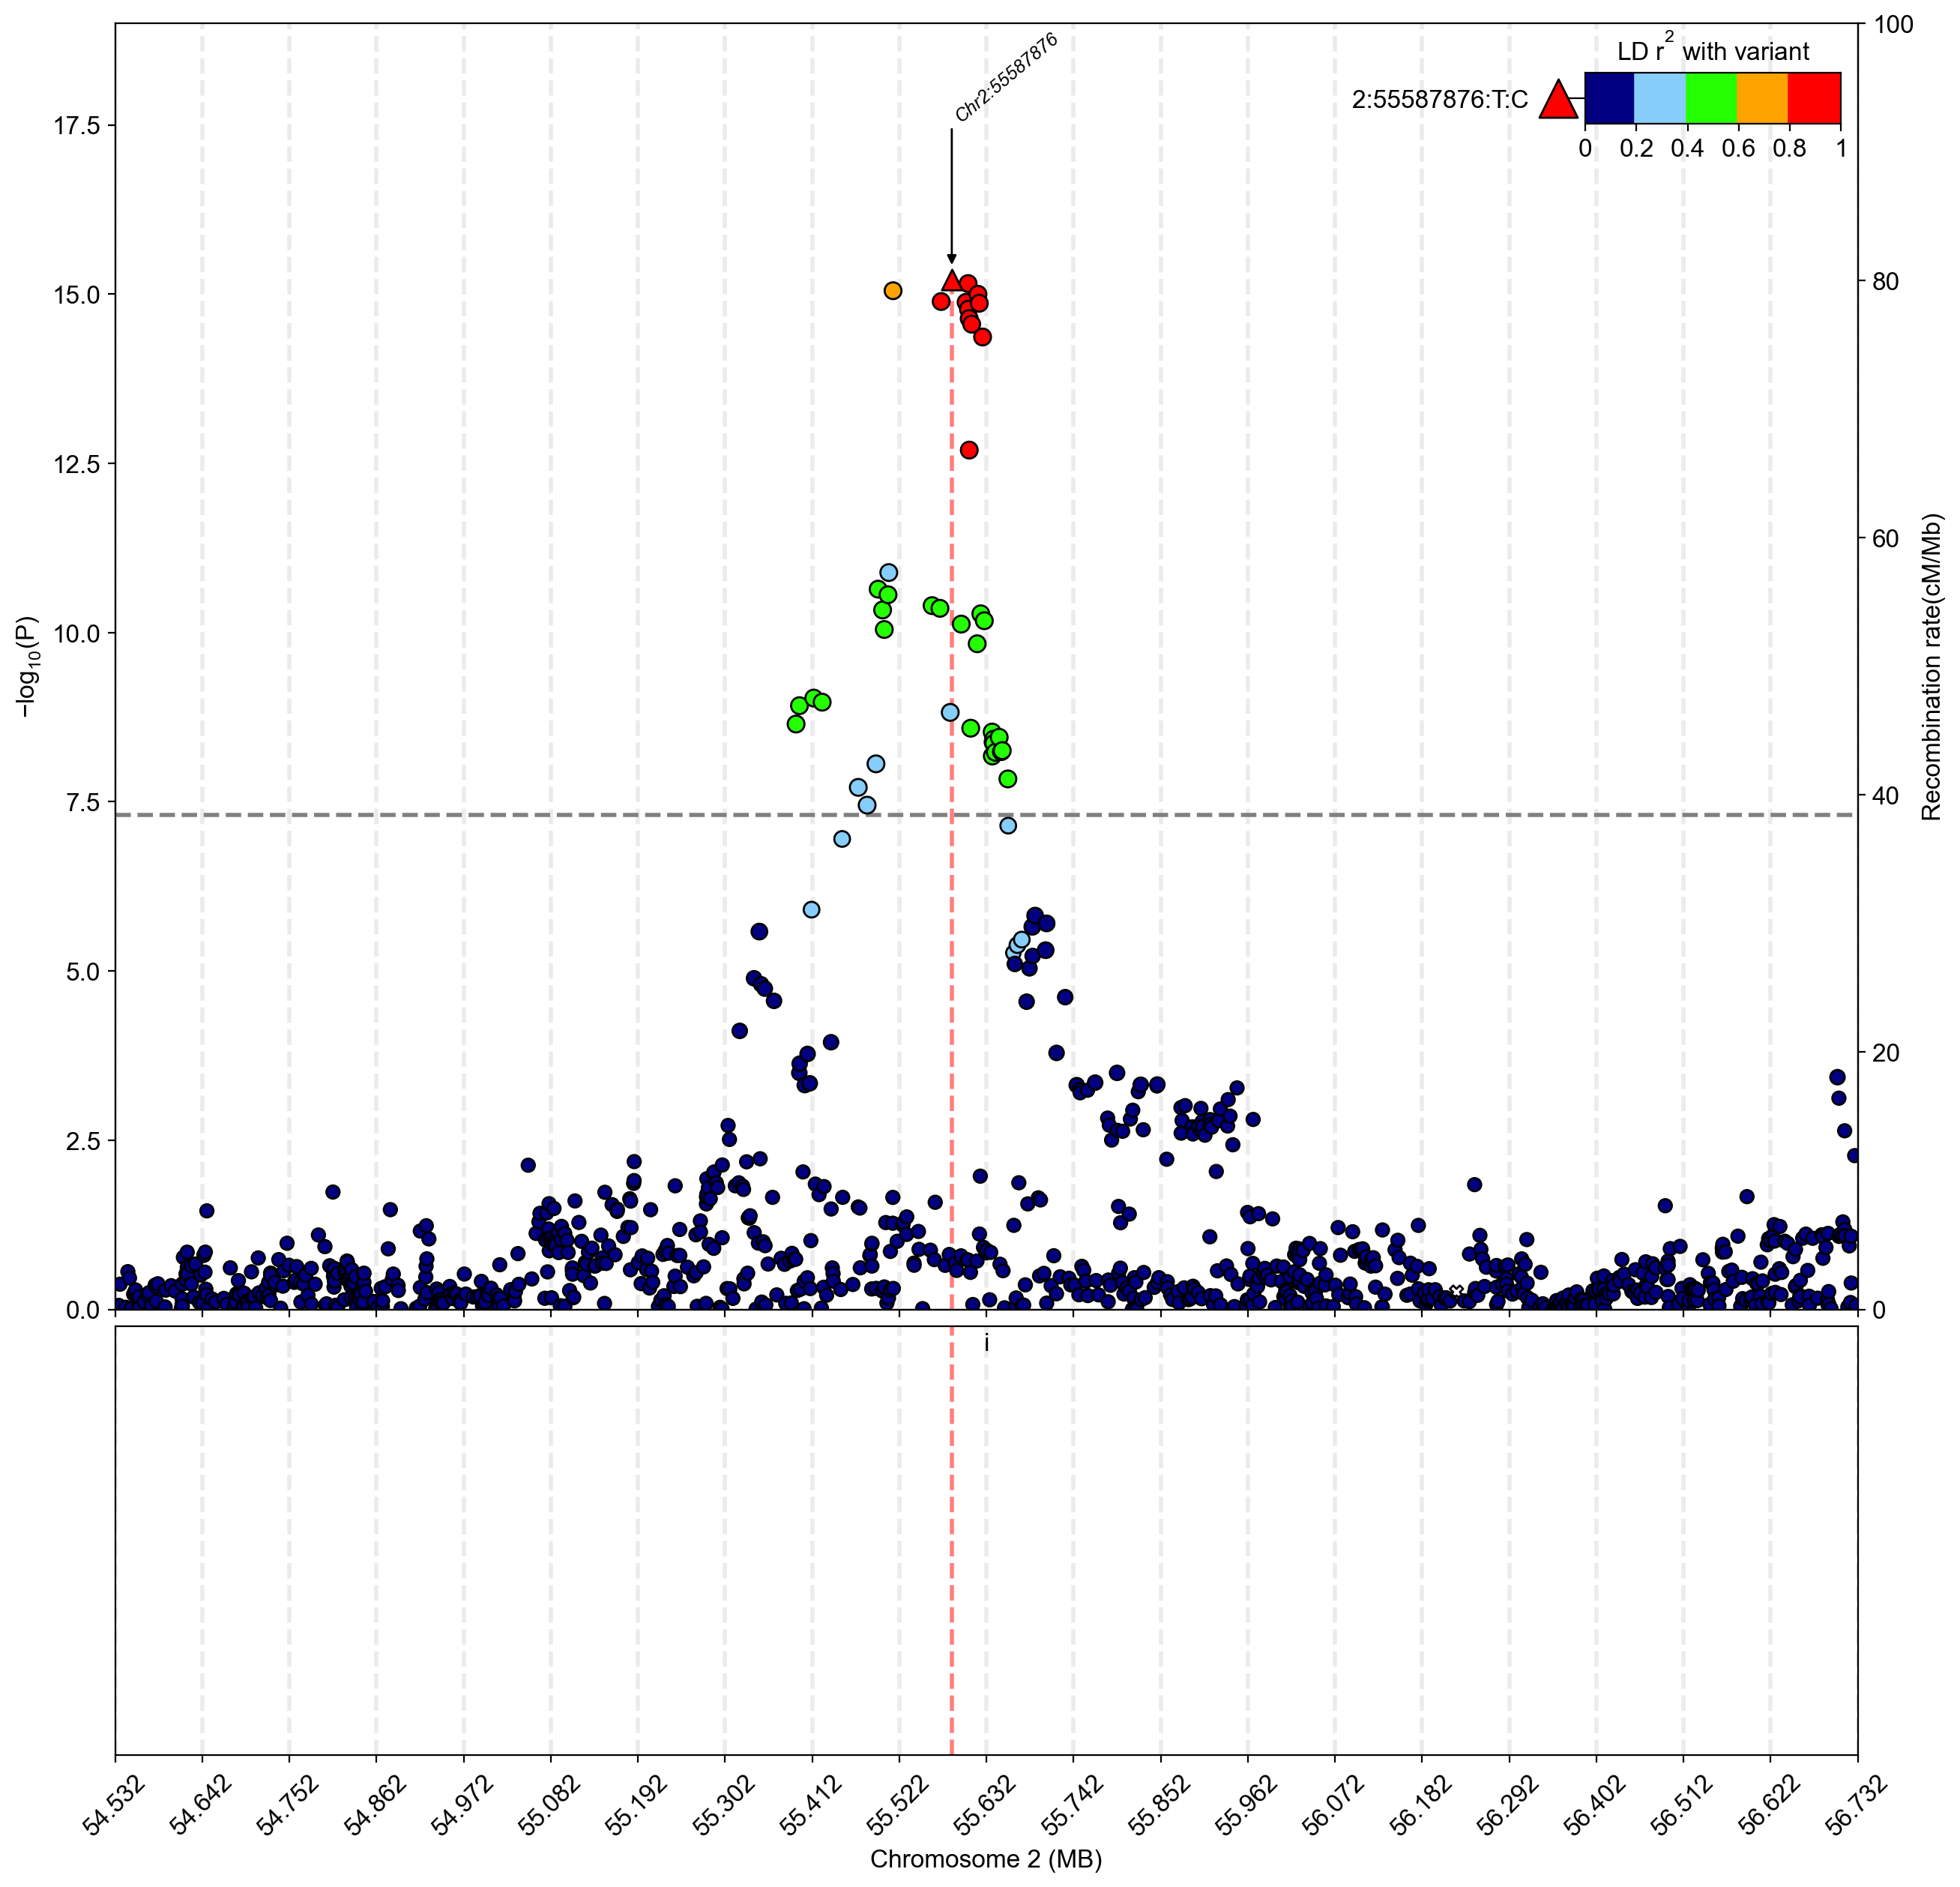

In [5]:
# Plot the exact same region, overlay the LD information
sumstats.plot_mqq(
    mode="r",
    anno=True,
    region=(2, 54531536, 56731536),
    region_grid=True,
    vcf_path=gl.get_path("1kg_eas_hg19"), # Tells it to use the downloaded panel
    build="19",
    save=True
)

In [ ]:
#this code creates a regional plot (also known as a locus zoom plot) for the same region as before, 
# but now it overlays the LD information. The LD information is obtained from the 1000 Genomes East Asian (EAS) 
# reference panel for hg19, which was downloaded in the previous step. LD stands for linkage disequilibrium, 
# which is a measure of the non-random association of alleles at different loci in a given population. 
# In other words, non-random association means that certain alleles at different loci tend to be inherited 
# together more often than would be expected by chance. 

# This gives a heatmap almost showing the strength of the LD between the variants in this region, 
# which can help us identify other variants that are in strong LD with the lead variant, and may 
# also be associated with the trait of interest. 

#GWAS analysis is a powerful tool for identifying genetic variants associated with traits or diseases,
# and visualizing the results through plots such as Manhattan plots, QQ plots, and regional plots
# can help us interpret the results and identify significant associations.
#It allows us to map how a specific trait is associated with specific genetic variants across the genome, and 
# can provide insights whereas PheWAS allows us to explore the associations between a single genetic variant 
# and a wide range of phenotypes


In [29]:
import gwaslab as gl

# 1. Define the lead SNP and path
target_snp = "2:55587876"
vcf_path = "/Users/noushinhaque/.gwaslab/EAS.ALL.split_norm_af.1kgp3v5.hg19.vcf.gz"

# 2. Use the LD module's specific calculation function
# We pass the sumstats.data (the underlying dataframe) directly
ld_df = gl.ld.calc_ld(
    sumstats=sumstats,
    target=target_snp,
    vcf_path=vcf_path,
    windowsizekb=1000,
    build="19"
)

# 3. View the correlation table
print("Linkage Disequilibrium (r2) Table:")
display(ld_df[['SNPID', 'POS', 'r2']].sort_values(by="r2", ascending=False).head(20))

AttributeError: module 'gwaslab' has no attribute 'ld'